In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('deliveries.csv')

In [3]:
df

,match_no,date,stage,venue,batting_team,bowling_team,innings,over,striker,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder
0,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.1,Travis Head,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
1,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.2,Travis Head,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN
2,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.3,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
3,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.4,Abhishek Sharma,Jacob Duffy,6,0,0,0,0,0,NaN,NaN,NaN
4,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.5,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17472,74,"May 31, 2026",Final,"Narendra Modi Stadium, Ahmedabad",RCB,GT,2,17.2,Virat Kohli,Arshad Khan,1,0,0,0,0,0,NaN,NaN,NaN
17473,74,"May 31, 2026",Final,"Narendra Modi Stadium, Ahmedabad",RCB,GT,2,17.3,Jitesh Sharma,Arshad Khan,0,0,0,0,0,0,NaN,NaN,NaN
17474,74,"May 31, 2026",Final,"Narendra Modi Stadium, Ahmedabad",RCB,GT,2,17.4,Jitesh Sharma,Arshad Khan,1,0,0,0,0,0,NaN,NaN,NaN
17475,74,"May 31, 2026",Final,"Narendra Modi Stadium, Ahmedabad",RCB,GT,2,17.5,Virat Kohli,Arshad Khan,4,0,0,0,0,0,NaN,NaN,NaN


In [4]:
df.shape

(17477, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17477 entries, 0 to 17476
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_no          17477 non-null  int64  
 1   date              17477 non-null  object 
 2   stage             17477 non-null  object 
 3   venue             17477 non-null  object 
 4   batting_team      17477 non-null  object 
 5   bowling_team      17477 non-null  object 
 6   innings           17477 non-null  int64  
 7   over              17477 non-null  float64
 8   striker           17477 non-null  object 
 9   bowler            17477 non-null  object 
 10  runs_of_bat       17477 non-null  int64  
 11  extras            17477 non-null  int64  
 12  wide              17477 non-null  int64  
 13  legbyes           17477 non-null  int64  
 14  byes              17477 non-null  int64  
 15  noballs           17477 non-null  int64  
 16  wicket_type       879 non-null    object

In [5]:
df.isnull().sum()

match_no                0
date                    0
stage                   0
venue                   0
batting_team            0
bowling_team            0
innings                 0
over                    0
striker                 0
bowler                  0
runs_of_bat             0
extras                  0
wide                    0
legbyes                 0
byes                    0
noballs                 0
wicket_type         16598
player_dismissed    16602
fielder             16791
dtype: int64

In [6]:
teams=pd.concat([df['batting_team'],df['bowling_team']]).unique()
teams

array(['SRH', 'RCB', 'KKR', 'MI', 'CSK', 'RR', 'GT', 'PBKS', 'LSG', 'DC'],
      dtype=object)

In [7]:
players=pd.concat([df['bowler'],df['striker']]).unique()
players

array(['Jacob Duffy', 'Bhuvneshwar Kumar', 'Abhinandan Singh',
       'Romario Shepherd', 'Suyash Sharma', 'Krunal Pandya',
       'Nitish Reddy', 'Jaydev Unadkat', 'David Payne', 'Harsh Dubey',
       'Eshan Malinga', 'Harshal Patel', 'Trent Boult', 'Hardik Pandya',
       'AM Ghazanfar', 'Jasprit Bumrah', 'Shardul Thakur',
       'Mayank Markande', 'Vaibhav Arora', 'Blessing Muzarabani',
       'Varun Chakaravarthy', 'Kartik Tyagi', 'Sunil Narine',
       'Anukul Roy', 'Jofra Archer', 'Nandre Burger', 'Brijesh Sharma',
       'Sandeep Sharma', 'Ravi Bishnoi', 'Ravindra Jadeja', 'Matt Henry',
       'Khaleel Ahmed', 'Anshul Kamboj', 'Noor Ahmad', 'Jamie Overton',
       'Matthew Short', 'Arshdeep Singh', 'Xavier Bartlett',
       'Marco Jansen', 'Vijaykumar Vyshak', 'Yuzvendra Chahal',
       'Mohammed Siraj', 'Kagiso Rabada', 'Ashok Sharma', 'Rashid Khan',
       'Washington Sundar', 'Prasidh Krishna', 'Mukesh Kumar',
       'Lungi Ngidi', 'Axar Patel', 'Natarajan', 'Kuldeep Yadav',


In [9]:
#KPIS
#1.Total Matches

total_matches = df['match_no'].nunique()

print("Total Matches:", total_matches)

Total Matches: 74


In [10]:
#2.Highest Run Scorer
top_runs = (
    df.groupby('striker')['runs_of_bat']
      .sum()
      .sort_values(ascending=False)
)

print(top_runs.head())

striker
Vaibhav Sooryavanshi    776
Shubman Gill            732
Sai Sudharsan           722
Virat Kohli             675
Heinrich Klaasen        624
Name: runs_of_bat, dtype: int64


In [11]:
#3.Highest Wicket Taker

wickets = df[df['player_dismissed'].notna()]

top_wickets = (
    wickets.groupby('bowler')
           .size()
           .sort_values(ascending=False)
)

print(top_wickets.head())

bowler
Bhuvneshwar Kumar    29
Kagiso Rabada        29
Jofra Archer         29
Anshul Kamboj        24
Eshan Malinga        21
dtype: int64


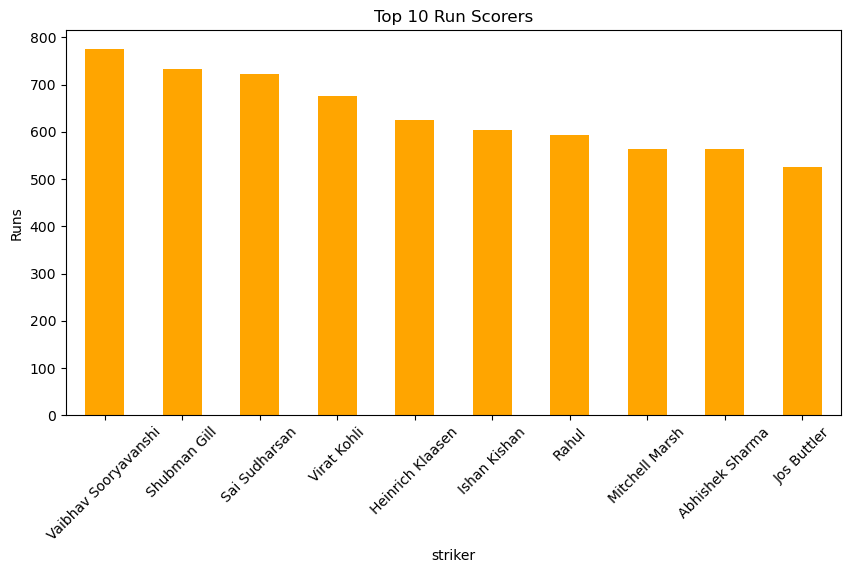

In [36]:
#Highest Run Scorer
plt.figure(figsize=(10,5))

top_runs.head(10).plot(kind='bar', color='orange')

plt.ylabel("Runs")

plt.title("Top 10 Run Scorers")

plt.xticks(rotation=45)

plt.show()

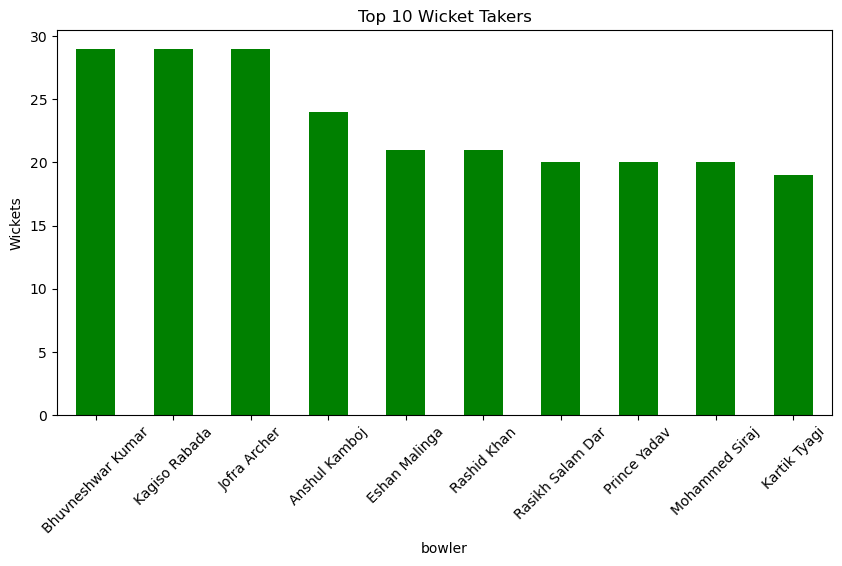

In [37]:
#Top 10 Wicket Takers
plt.figure(figsize=(10,5))

top_wickets.head(10).plot(kind='bar', color='green')

plt.ylabel("Wickets")

plt.title("Top 10 Wicket Takers")

plt.xticks(rotation=45)

plt.show()

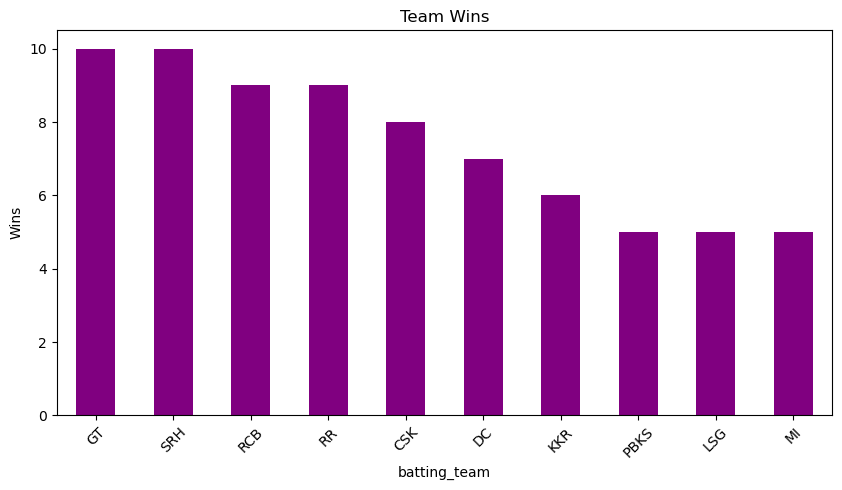

In [38]:
#Team Wins
plt.figure(figsize=(10,5))

team_wins.plot(kind='bar', color='purple')

plt.ylabel("Wins")

plt.title("Team Wins")

plt.xticks(rotation=45)

plt.show()

In [32]:
total_teams = df['batting_team'].nunique()
total_fours = (df['runs_of_bat'] == 4).sum()

# Total Sixes
total_sixes = (df['runs_of_bat'] == 6).sum()


In [34]:
# ---------------- IPL 2026 KPI Dashboard ---------------- #

print("=" * 60)
print("          IPL 2026 DASHBOARD KPI SUMMARY")
print("=" * 60)

print(f"🏏 Total Matches         : {total_matches}")
print(f"👥 Total Teams           : {total_teams}")
print(f"🏃 Total Fours           : {total_fours}")
print(f"💥 Total Sixes           : {total_sixes}")

print("-" * 60)

print(f"🥇 Highest Run Scorer    : {top_runs.idxmax()} ({top_runs.max()} Runs)")
print(f"🎯 Highest Wicket Taker  : {top_wickets.idxmax()} ({top_wickets.max()} Wickets)")
print(f"🏆 Most Successful Team  : {team_wins.idxmax()} ({team_wins.max()} Wins)")

print("=" * 60)

          IPL 2026 DASHBOARD KPI SUMMARY
🏏 Total Matches         : 74
👥 Total Teams           : 10
🏃 Total Fours           : 2333
💥 Total Sixes           : 1426
------------------------------------------------------------
🥇 Highest Run Scorer    : Vaibhav Sooryavanshi (776 Runs)
🎯 Highest Wicket Taker  : Bhuvneshwar Kumar (29 Wickets)
🏆 Most Successful Team  : GT (10 Wins)


In [9]:
df['player_dismissed'].notna().sum()

875

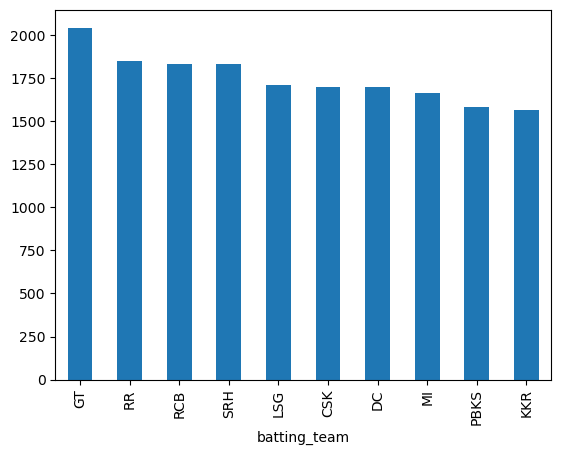

In [35]:
# deliveries faced
df['batting_team'].value_counts().plot(kind='bar')
plt.show()

In [13]:
total_runs=(df['runs_of_bat']+df['extras']).sum()
total_runs

27396

In [14]:
total_wickets=df['player_dismissed'].notna().sum()
total_wickets

875

In [15]:
total_boundaries=fours+sixes
total_boundaries

3759

In [16]:
boundary_runs=(fours*4+(sixes*6))
boundary_runs

17888

In [17]:
boundary_runs_percent=(boundary_runs/total_runs)*100
boundary_runs_percent.round(2)

65.29

In [18]:
dot_balls=(df['runs_of_bat']==0).sum()
dot_balls_percent=(dot_balls/len(df))*100

In [19]:
dot_balls_percent.round(2)

36.95

In [20]:
runs_dist=df['runs_of_bat'].value_counts().reset_index()
runs_dist

,index,runs_of_bat
0,0,6458
1,1,6308
2,4,2333
3,6,1426
4,2,913
5,3,32
6,5,7


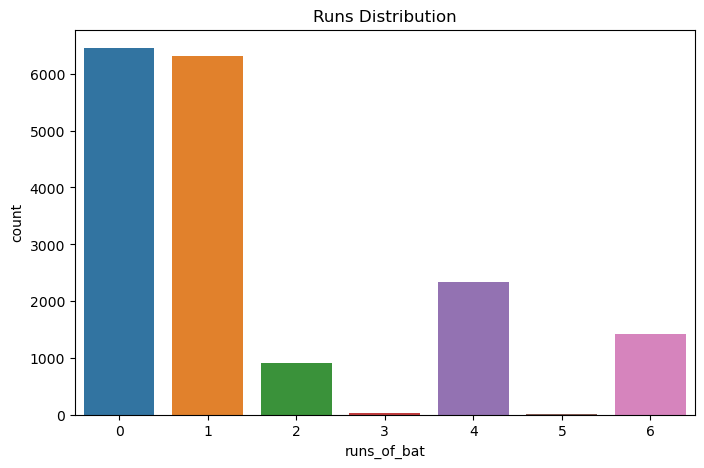

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x='runs_of_bat',data=df)
plt.title('Runs Distribution')
plt.show()

In [22]:
total_extras=df['extras'].sum()
total_extras

1243

In [23]:
powerplay =df[df['over']<=6]
middle=df[(df['over']>6 & (df['over']<=15))]
death=df[df['over']>15]

phases={
    "Powerplay":(powerplay['runs_of_bat']+powerplay['extras']).sum(),
    "Middle Overs":(middle['runs_of_bat']+middle['extras']).sum(),
    "Death Overs":(death['runs_of_bat']+death['extras']).sum()
}
phases

{'Powerplay': 8873, 'Middle Overs': 27396, 'Death Overs': 6511}

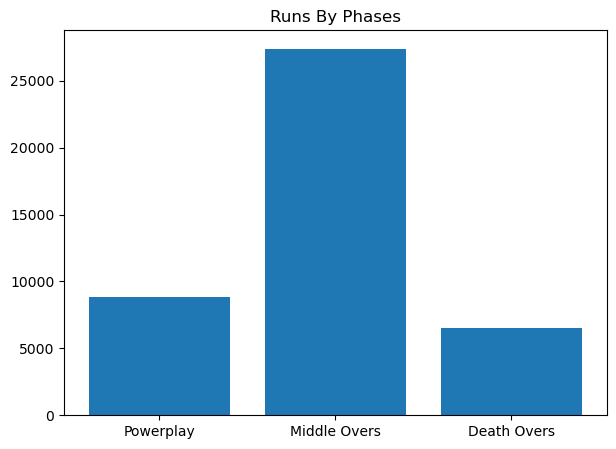

In [24]:
plt.figure(figsize=(7,5))
plt.bar(phases.keys(),phases.values())
plt.title("Runs By Phases")
plt.show()

# Team Analysis

In [25]:
team_runs=df.groupby('batting_team')[['runs_of_bat','extras']].sum()
team_runs.sort_values('runs_of_bat',ascending=False)

,runs_of_bat,extras
batting_team,,
RR,2951,120
GT,2935,148
RCB,2914,140
SRH,2903,138
PBKS,2589,115
MI,2455,97
DC,2422,130
CSK,2390,133
LSG,2380,125


In [26]:
team_runs['total_runs']=team_runs['runs_of_bat']+team_runs['extras']
team_runs.sort_values('runs_of_bat',ascending=False)

,runs_of_bat,extras,total_runs
batting_team,,,
RR,2951,120,3071
GT,2935,148,3083
RCB,2914,140,3054
SRH,2903,138,3041
PBKS,2589,115,2704
MI,2455,97,2552
DC,2422,130,2552
CSK,2390,133,2523
LSG,2380,125,2505


<Axes: xlabel='batting_team', ylabel='total_runs'>

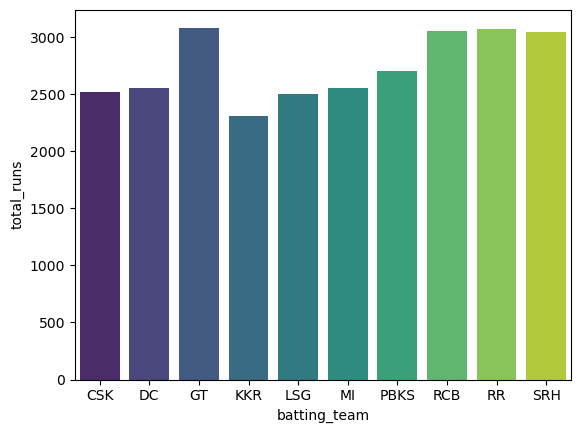

In [27]:
sns.barplot(x=team_runs.index,y=team_runs['total_runs'],palette='viridis')

# Boundary Percentages

In [29]:
boundary_df=df[(df['runs_of_bat']==4) | (df['runs_of_bat']==6)]

team_boundaries=boundary_df.groupby('batting_team').size()
team_boundaries

batting_team
CSK     344
DC      342
GT      416
KKR     307
LSG     335
MI      344
PBKS    382
RCB     425
RR      438
SRH     426
dtype: int64

In [33]:
team_wickets=df[df['player_dismissed'].notna()]
team_wickets=team_wickets.groupby('batting_team').size()
team_wickets.sort_values(ascending=False)

batting_team
SRH     100
RR       98
LSG      95
GT       91
MI       90
DC       85
CSK      83
RCB      83
KKR      76
PBKS     74
dtype: int64

# Venue Analysis

In [53]:
venue_match=df.groupby('venue')['match_no'].nunique()
venue_match.sort_values(ascending=False)

venue
Narendra Modi Stadium, Ahmedabad                                                      8
Arun Jaitley Stadium, Delhi                                                           7
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow                 7
Eden Gardens, Kolkata                                                                 7
MA Chidambaram Stadium, Chennai                                                       7
Rajiv Gandhi International Stadium, Hyderabad                                         7
Wankhede Stadium, Mumbai                                                              7
Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur, New Chandigarh    6
M.Chinnaswamy Stadium, Bengaluru                                                      5
Himachal Pradesh Cricket Association Stadium, Dharamsala                              4
Sawai Mansingh Stadium, Jaipur                                                        4
Barsapara Cricket Stadium,

<Axes: xlabel='venue'>

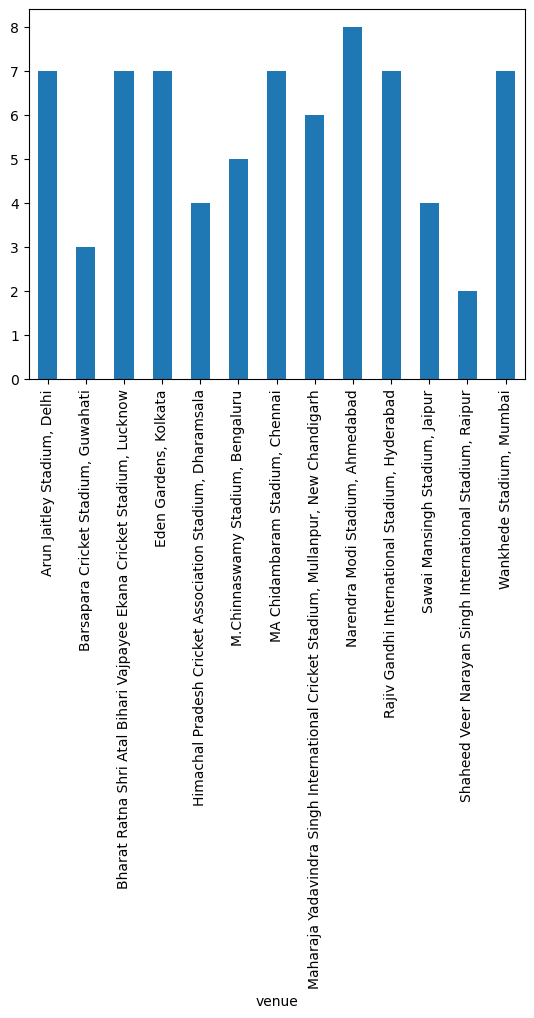

In [54]:
venue_match.plot(kind='bar')

In [60]:
venue_avg=df.groupby('venue').agg({
    'runs_of_bat':'sum',
    'extras':'sum',
    'match_no':'nunique'
})
venue_avg['avg_runs']=((venue_avg['runs_of_bat']+venue_avg['extras'])/venue_avg['match_no'])

venue_avg['avg_runs_per_innings']=(((venue_avg['runs_of_bat']+venue_avg['extras'])/venue_avg['match_no'])/2)
venue_avg['avg_runs_per_innings'].round(2).sort_values(ascending=False)

venue
Sawai Mansingh Stadium, Jaipur                                                        216.00
Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur, New Chandigarh    211.75
Wankhede Stadium, Mumbai                                                              209.50
Himachal Pradesh Cricket Association Stadium, Dharamsala                              208.12
Rajiv Gandhi International Stadium, Hyderabad                                         194.57
M.Chinnaswamy Stadium, Bengaluru                                                      192.30
MA Chidambaram Stadium, Chennai                                                       183.86
Shaheed Veer Narayan Singh International Stadium, Raipur                              179.50
Arun Jaitley Stadium, Delhi                                                           172.43
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow                 170.43
Narendra Modi Stadium, Ahmedabad                                

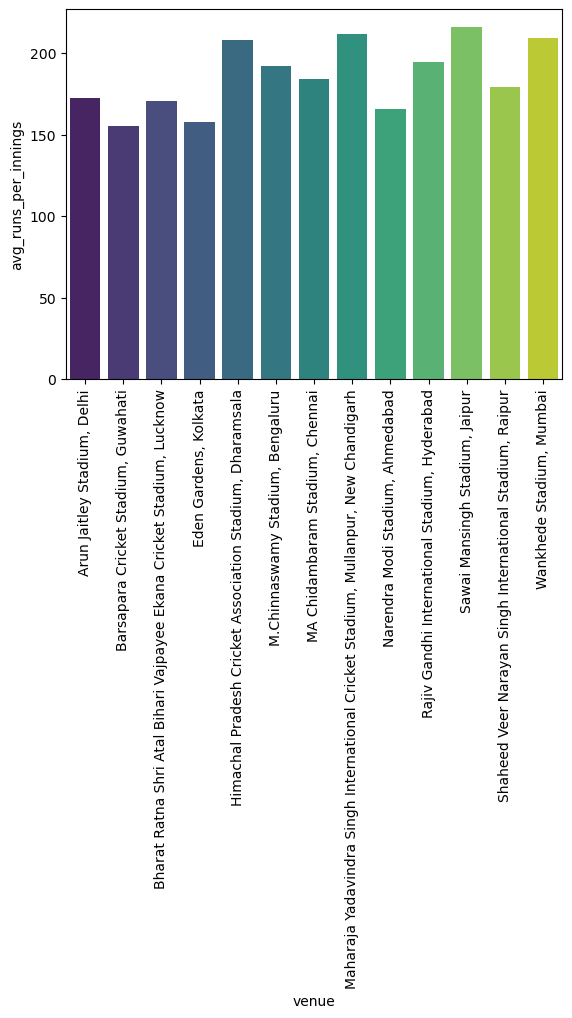

In [66]:
sns.barplot(x=venue_avg.index,y=venue_avg['avg_runs_per_innings'],palette='viridis')
plt.xticks(rotation=90)
plt.show()

In [72]:
dot_balls={
     "Powerplay":(powerplay['runs_of_bat']==0).sum(),
    "Middle Overs":(middle['runs_of_bat']==0).sum(),
    "Death Overs":(death['runs_of_bat']==0).sum()
}
dot_balls

{'Powerplay': 2506, 'Middle Overs': 6458, 'Death Overs': 1349}

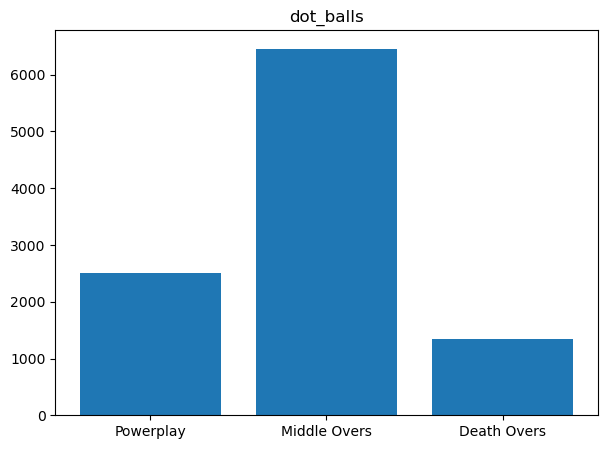

In [74]:
plt.figure(figsize=(7,5))
plt.bar(dot_balls.keys(),dot_balls.values())
plt.title("dot_balls")
plt.show()

# Batter Bowler Rivalries

In [77]:
rivalry=df[df['player_dismissed'].notna()].groupby(['bowler','player_dismissed']).size().reset_index(name='Dismissals')
rivalry.sort_values('Dismissals',ascending=False)

,bowler,player_dismissed,Dismissals
730,Shivang Kumar,Angkrish Raghuvanshi,2
286,Jofra Archer,Abhishek Sharma,2
245,Jacob Duffy,Sai Sudharsan,2
140,Bhuvneshwar Kumar,Shubman Gill,2
560,Praful Hinge,Dhruv Jurel,2
597,Prince Yadav,Jitesh Sharma,2
468,Mohammed Siraj,Ajinkya Rahane,2
291,Jofra Archer,Ishan Kishan,2
472,Mohammed Siraj,Jacob Bethell,2
288,Jofra Archer,Ayush Badoni,2


Most Expensive Bowler

In [86]:
bowler_runs.sort_values('runs_conceded',ascending=False).head()

,runs_of_bat,extras,runs_conceded
bowler,,,
Kagiso Rabada,613,18,631
Mohammed Siraj,544,24,568
Jofra Archer,528,37,565
Arshdeep Singh,509,30,539
Anshul Kamboj,514,18,532


In [89]:
pair_runs=df.groupby(['striker','bowler'])['runs_of_bat'].sum().reset_index()
pair_runs.sort_values('runs_of_bat',ascending=False).head(10)

,striker,bowler,runs_of_bat
3046,Virat Kohli,Kagiso Rabada,88
908,Ishan Kishan,Jofra Archer,74
2974,Vaibhav Sooryavanshi,Mohammed Siraj,60
2384,Sanju Samson,Natarajan,60
2983,Vaibhav Sooryavanshi,Sakib Hussain,59
2979,Vaibhav Sooryavanshi,Praful Hinge,57
438,Cameron Green,Rashid Khan,54
2671,Shubman Gill,Varun Chakaravarthy,51
1782,Rahul,Arshdeep Singh,48
2261,Sai Sudharsan,Gurjapneet Singh,48


# Lucky Venue

In [93]:
venue_team_runs=df.groupby(['venue','batting_team']).agg({
    'runs_of_bat':'sum',
    'extras':'sum'
})

venue_team_runs['runs']=(venue_team_runs['runs_of_bat']+venue_team_runs['extras'])
venue_team_runs.sort_values('runs',ascending=False).head(10)

,,runs_of_bat,extras,runs
venue,batting_team,,,
"Rajiv Gandhi International Stadium, Hyderabad",SRH,1400,59,1459
"Wankhede Stadium, Mumbai",MI,1340,51,1391
"Narendra Modi Stadium, Ahmedabad",GT,1296,62,1358
"MA Chidambaram Stadium, Chennai",CSK,1249,66,1315
"Arun Jaitley Stadium, Delhi",DC,1162,43,1205
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",LSG,1105,67,1172
"Eden Gardens, Kolkata",KKR,1042,43,1085
"M.Chinnaswamy Stadium, Bengaluru",RCB,936,47,983
"Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur, New Chandigarh",PBKS,837,26,863
